In [ ]:
#Code with the topic : Decision Tree Missing Data 

#Objective:

#Build a Decision Tree Classification model to predict loan approval status.
#The project focuses on handling missing data, preprocessing categorical
#and numerical variables, training the model, and evaluating its performance.

#Technologies used:

#Pandas 
#Matplotlib
#Python 
#Jupyter notebook 
#Visual Studio Code 

#Methology:

# 1. Load and explore the dataset.
# 2. Identify missing values and variable types.
# 3. Handle missing numerical and categorical data.
# 4. Convert categorical variables into numerical features.
# 5. Split the dataset into training and testing sets.
# 6. Train a Decision Tree Classifier.
# 7. Evaluate the model using accuracy and classification metrics.
# 8. Analyze feature importance and visualize the decision tree.

In [5]:
#We import the libraries:

import pandas as pd 
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split 
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer 

In [6]:
#Load the dataset 

data = pd.read_csv("Decision_Tree_Missing_Data.csv")

In [7]:
#Visualization

data.head()

,Age,Income,Education,Employment_Years,Credit_Score,Loan_Amount,Loan_Status
0,25,30000.0,High School,2.0,580.0,10000.0,Rejected
1,32,45000.0,College,5.0,650.0,15000.0,Approved
2,41,NaN,University,10.0,720.0,20000.0,Approved
3,29,35000.0,NaN,4.0,610.0,12000.0,Rejected
4,45,60000.0,University,15.0,750.0,25000.0,Approved


In [8]:
data.describe()

,Age,Income,Employment_Years,Credit_Score,Loan_Amount
count,20.000000,17.000000,17.000000,18.000000,19.000000
mean,36.150000,48823.529412,8.941176,679.444444,17789.473684
std,9.653333,16268.202475,6.950455,80.108178,8066.246183
min,23.000000,28000.000000,1.000000,560.000000,7000.000000
25%,28.500000,35000.000000,4.000000,612.500000,11500.000000
50%,35.000000,48000.000000,7.000000,685.000000,16000.000000
75%,43.500000,60000.000000,12.000000,745.000000,23500.000000
max,55.000000,80000.000000,25.000000,810.000000,35000.000000


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               20 non-null     int64  
 1   Income            17 non-null     float64
 2   Education         18 non-null     object 
 3   Employment_Years  17 non-null     float64
 4   Credit_Score      18 non-null     float64
 5   Loan_Amount       19 non-null     float64
 6   Loan_Status       20 non-null     object 
dtypes: float64(4), int64(1), object(2)
memory usage: 1.2+ KB


In [10]:
#Check for missing data 

print("\n===== MISSING DATA =====")

missing_values = data.isnull().sum()

print(missing_values)

print("\nTotal missing values:")
print(data.isnull().sum().sum())


===== MISSING DATA =====
Age                 0
Income              3
Education           2
Employment_Years    3
Credit_Score        2
Loan_Amount         1
Loan_Status         0
dtype: int64

Total missing values:
11


In [11]:
#Separate features and target 

X = data.drop("Loan_Status", axis=1)
y = data["Loan_Status"]

In [12]:
#Identify numerical and categorical columns

numeric_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_columns = X.select_dtypes(
    include=["object"]
).columns


print("\nNumerical columns:")
print(list(numeric_columns))

print("\nCategorical columns:")
print(list(categorical_columns))



Numerical columns:
['Age', 'Income', 'Employment_Years', 'Credit_Score', 'Loan_Amount']

Categorical columns:
['Education']


In [13]:
#Handle missing numerical data 

numeric_imputer = SimpleImputer(strategy="median")

X[numeric_columns] = numeric_imputer.fit_transform(
    X[numeric_columns]
)



In [14]:
#Handle missing categorical data 


categorical_imputer = SimpleImputer(
    strategy="most_frequent"
)

X[categorical_columns] = categorical_imputer.fit_transform(
    X[categorical_columns]
)



In [15]:
#Convert categorical data into numerical data 

X = pd.get_dummies(
    X,
    drop_first=True
)



In [16]:
#Split data into training and testing sets 

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [17]:
#Create the Decision Tree 

decision_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)



In [18]:
#Train the model 

decision_tree.fit(
    X_train,
    y_train
)



,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [19]:
#Make predictions 

y_pred = decision_tree.predict(X_test)




In [20]:
#Evaluate the model 

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n===== MODEL RESULTS =====")

print("Accuracy:")
print(f"{accuracy:.2%}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)





===== MODEL RESULTS =====
Accuracy:
75.00%

Classification Report:
              precision    recall  f1-score   support

    Approved       0.67      1.00      0.80         2
    Rejected       1.00      0.50      0.67         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



In [21]:
#Feature Importance


feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": decision_tree.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n===== FEATURE IMPORTANCE =====")
print(feature_importance)


===== FEATURE IMPORTANCE =====
                 Feature  Importance
3           Credit_Score         1.0
1                 Income         0.0
0                    Age         0.0
2       Employment_Years         0.0
4            Loan_Amount         0.0
5  Education_High School         0.0
6   Education_University         0.0


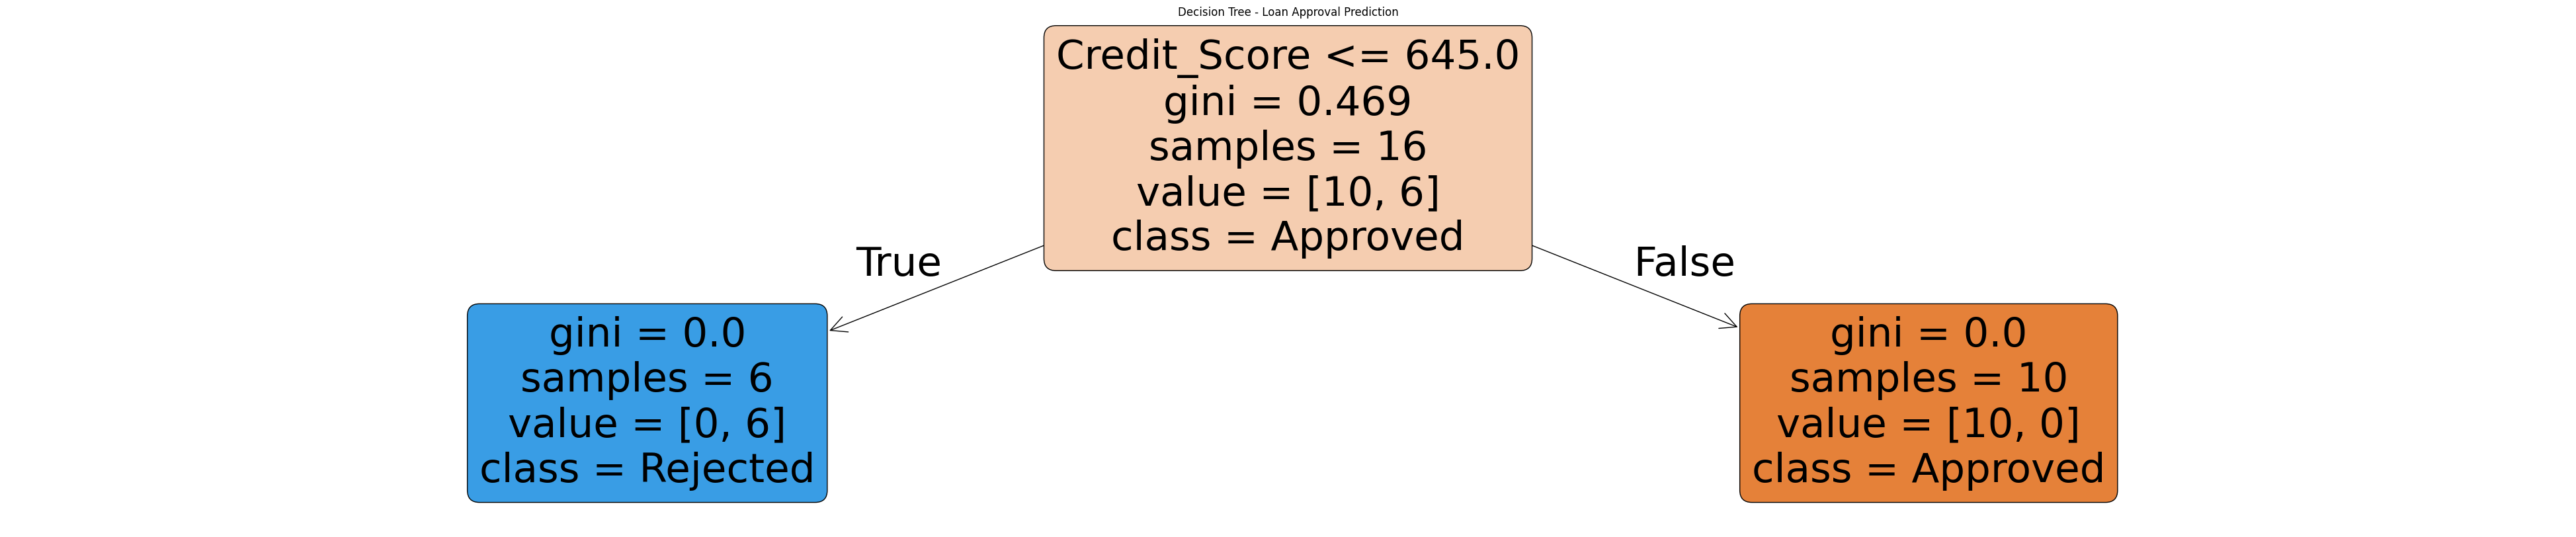

In [23]:
#Visualize the decision tree 

plt.figure(
    figsize=(50, 10)
)

plot_tree(
    decision_tree,
    feature_names=X.columns,
    class_names=decision_tree.classes_,
    filled=True,
    rounded=True
)

plt.title(
    "Decision Tree - Loan Approval Prediction"
)

plt.show()